In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA PIPELINE: EXTRACTION

In [7]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   --------- ----------------------------- 61.4/250.9 kB 233.8 kB/s eta 0:00:01
   -------------- ------------------------ 92.2/250.9 kB 291.5 kB/s eta 0:00:01
   --------------- ---------------------- 102.4/250.9 kB 295.4 kB/s eta 0:00:01
   --------------- ---------------------- 102.4/250.9 kB 295.4 kB/s eta 0:00:01
   --------------- ---------------------- 102.4/250.9 kB 295.4 kB/s eta 0:00:01
   --------------- -


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
df = pd.DataFrame(pd.read_excel("Flight_Fare.xlsx"))

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


# 2. DATA PIPELINE: CLEANING & TRANSFORMATION

In [12]:


print("Cleaning data...")

# A. Handle Dates for 'Macroeconomic pricing trends' & 'Weekend drops'
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Journey_Weekday'] = pd.Categorical(df['Date_of_Journey'].dt.day_name(), categories=cats, ordered=True)

# B. Handle Departure Time for 'Time-of-day premiums'
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time'], format='mixed').dt.hour
def get_time_of_day(hour):
    if 4 <= hour < 8: return 'Early Morning'
    elif 8 <= hour < 12: return 'Morning'
    elif 12 <= hour < 16: return 'Afternoon'
    elif 16 <= hour < 20: return 'Evening'
    else: return 'Night'

time_cats = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night']
df['Dep_Time_Bucket'] = pd.Categorical(df['Dep_Hour'].apply(get_time_of_day), categories=time_cats, ordered=True)

# C. Standardize Flight Duration for 'Strategic market positioning'
def convert_duration_to_minutes(duration):
    if pd.isna(duration): return 0
    parts = duration.split()
    hours, minutes = 0, 0
    for part in parts:
        if 'h' in part: hours = int(part.replace('h', ''))
        elif 'm' in part: minutes = int(part.replace('m', ''))
    return (hours * 60) + minutes
df['Duration_mins'] = df['Duration'].apply(convert_duration_to_minutes)

# D. Clean Stops
stops_mapping = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stops_mapping).fillna(0).astype(int)

Cleaning data...


# 3. VISUALIZATION & DASHBOARDING

In [13]:
print("Generating Dashboard Visualizations...")
sns.set_theme(style="whitegrid")

Generating Dashboard Visualizations...


#Plot 1: Time-of-Day Premiums ---

C:\Users\smaji\AppData\Local\Temp\ipykernel_29392\202317973.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Dep_Time_Bucket', y='Price', ax=ax1, errorbar=None, palette="viridis")


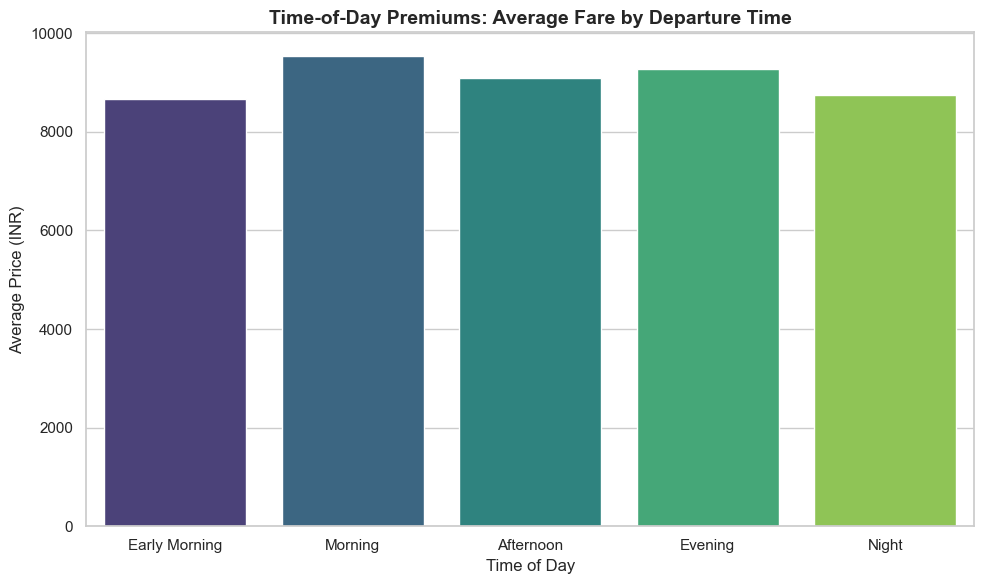

In [14]:

fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Dep_Time_Bucket', y='Price', ax=ax1, errorbar=None, palette="viridis")
ax1.set_title("Time-of-Day Premiums: Average Fare by Departure Time", fontsize=14, weight='bold')
ax1.set_xlabel("Time of Day", fontsize=12)
ax1.set_ylabel("Average Price (INR)", fontsize=12)
plt.tight_layout()
plt.savefig('time_of_day_premiums.png')
plt.show()


#Plot 2: Weekend Fare Drops & Fluctuations ---

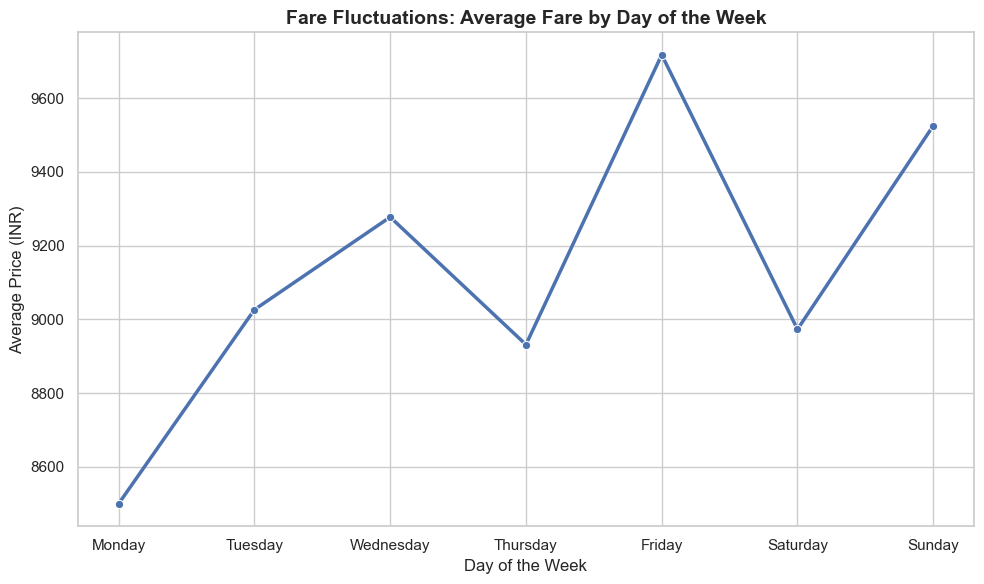

In [15]:

fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x='Journey_Weekday', y='Price', ax=ax2, marker="o", errorbar=None, color="b", linewidth=2.5)
ax2.set_title("Fare Fluctuations: Average Fare by Day of the Week", fontsize=14, weight='bold')
ax2.set_xlabel("Day of the Week", fontsize=12)
ax2.set_ylabel("Average Price (INR)", fontsize=12)
plt.tight_layout()
plt.savefig('weekend_fare_drops.png')
plt.show()



# Plot 3: Strategic Market Positioning

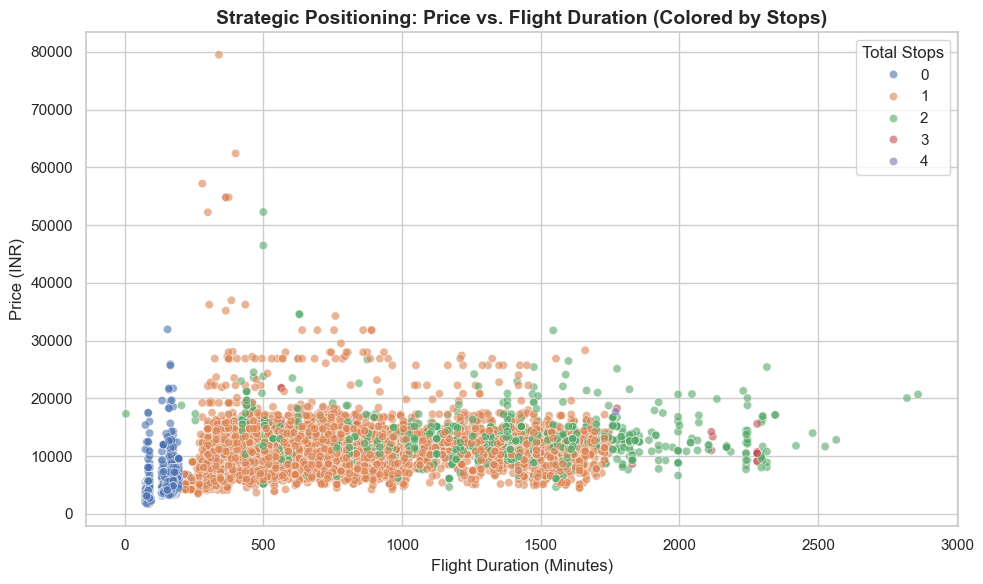

Project Execution Complete!


In [16]:

fig3, ax3 = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration_mins', y='Price', hue='Total_Stops', palette="deep", alpha=0.6, ax=ax3)
ax3.set_title("Strategic Positioning: Price vs. Flight Duration (Colored by Stops)", fontsize=14, weight='bold')
ax3.set_xlabel("Flight Duration (Minutes)", fontsize=12)
ax3.set_ylabel("Price (INR)", fontsize=12)
plt.legend(title="Total Stops")
plt.tight_layout()
plt.savefig('market_positioning.png')
plt.show()

print("Project Execution Complete!")